<a href="https://colab.research.google.com/github/Sethchiji/AI-Powered-News-Newsletter-Generator/blob/main/Copy_of_Datamining_GP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**PROBLEM DESCRIPTION**


1.   Online shopping platforms collect large amounts of user behavior data
2.   Businesses want to predict which browsing sessions
will end in purchases

Goal: To build machine learning models to predict
purchase intention.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Examine Duplicate and remove

In [ ]:
# Examine for duplicates, null values
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(df.isnull().sum())


Number of duplicate rows: 125
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [ ]:
# Drop duplicate rows
print(f"Original number of rows: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(df)}")

# Verify no duplicates remain
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")


Original number of rows: 12330
Number of rows after dropping duplicates: 12205
Number of duplicate rows after removal: 0


In [ ]:
# show uniques values of all columns
for col in df.columns:
    print(f'{col}: {df[col].unique()}')


Administrative: [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]
Administrative_Duration: [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]
Informational: [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]
Informational_Duration: [  0.   120.    16.   ... 547.75 368.25 211.25]
ProductRelated: [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 102 313 145  85  97 198 181 126 106 101 108 119
  70 122  91 276 100 291 114 172 217 141 133 156 136 180 135

#### Encoding Reveenue Label

Purchase = 0 No

Purchase = 1 Yes

In [ ]:
# one-hot encode revenue label
df['Revenue'] = df['Revenue'].apply(lambda x: 1 if x else 0)
df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0


In [ ]:
df[df['Revenue'] == 1].head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
65,3,87.833333,0,0.0,27,798.333333,0.000000,0.012644,22.916036,0.8,Feb,2,2,3,1,Returning_Visitor,False,1
76,10,1005.666667,0,0.0,36,2111.341667,0.004348,0.014493,11.439412,0.0,Feb,2,6,1,2,Returning_Visitor,False,1
101,4,61.000000,0,0.0,19,607.000000,0.000000,0.026984,17.535959,1.0,Feb,1,1,7,4,Returning_Visitor,True,1
188,9,111.500000,1,48.5,49,1868.819697,0.000000,0.020709,1.706015,0.0,Mar,2,2,7,2,Returning_Visitor,False,1
196,2,56.000000,1,144.0,67,2563.783333,0.000000,0.005797,19.342650,0.0,Mar,2,2,4,2,New_Visitor,False,1


### Target Variable Class Distribution

In [ ]:
# check for class imbalance on revenue
df['Revenue'].value_counts()

,count
Revenue,
0,10297
1,1908


/tmp/ipykernel_31077/2166174764.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='crest')


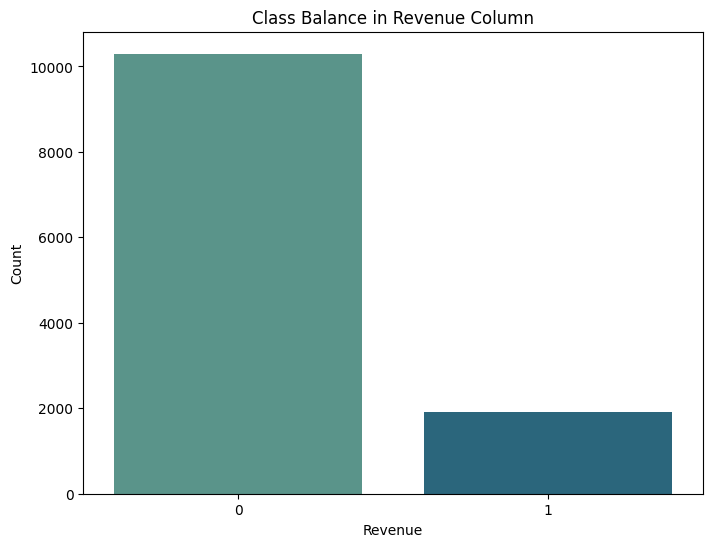

In [ ]:
# bar chart for class balance in our target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Revenue', data=df, palette='crest')
plt.title('Class Balance in Revenue Column')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.show()

### Visitor Type Behavior



Conversion Rate: Total number of people who visited the store and conmplete a purchase. So, to get that conversion rate, we grouped visitortype and revenue to get their mean.

In [ ]:
df['VisitorType'].value_counts()

,count
VisitorType,
Returning_Visitor,10431
New_Visitor,1693
Other,81


In [ ]:
# correlation of VisitorType to revenue
df.groupby('VisitorType')['Revenue'].mean()


,Revenue
VisitorType,
New_Visitor,0.249262
Other,0.197531
Returning_Visitor,0.140926


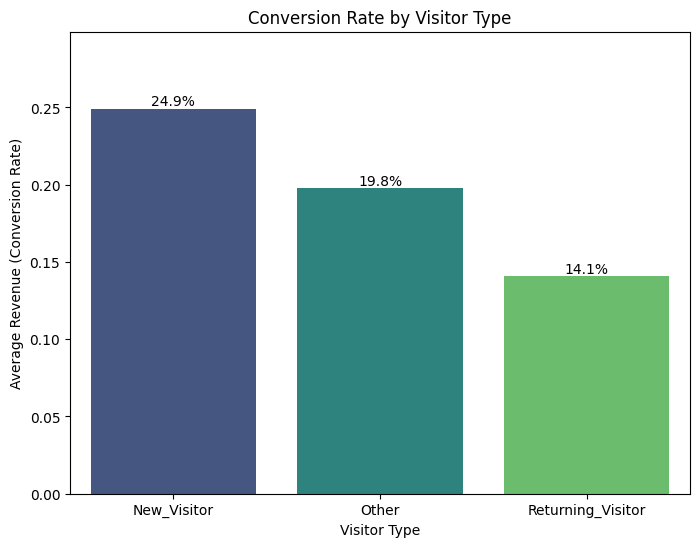

In [ ]:
conversion_rates = df.groupby('VisitorType')['Revenue'].mean().reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='VisitorType', y='Revenue', data=conversion_rates, hue='VisitorType', palette='viridis', legend=False)
plt.title('Conversion Rate by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Average Revenue (Conversion Rate)')
plt.ylim(0, conversion_rates['Revenue'].max() * 1.2)

# Added numerical labels on top of each bar, formatted as percentages
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.1f}%')

plt.show()

### Total Duration

This is the total time spent

In [ ]:
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

session_duration_by_visitor_type = df.groupby('VisitorType')['Total_Duration'].mean().reset_index()

display(session_duration_by_visitor_type)

,VisitorType,Total_Duration
0,New_Visitor,747.983690
1,Other,676.627222
2,Returning_Visitor,1421.878615


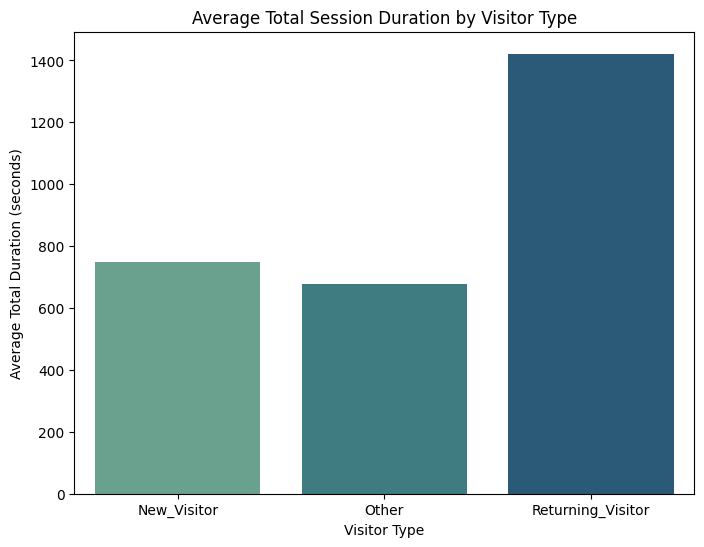

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='VisitorType', y='Total_Duration', data=session_duration_by_visitor_type, hue='VisitorType', palette='crest', legend=False)
plt.title('Average Total Session Duration by Visitor Type')
plt.xlabel('Visitor Type')
plt.ylabel('Average Total Duration (seconds)')
plt.show()

In [ ]:
df.groupby('VisitorType')['Revenue'].agg(['mean','sum','count'])

,mean,sum,count
VisitorType,,,
New_Visitor,0.249262,422,1693
Other,0.197531,16,81
Returning_Visitor,0.140926,1470,10431


Key Insight: This creates an interesting paradox: Returning visitors spend more time but convert less, while new visitors spend less time but convert more. This suggests that mere time spent on the site does not directly correlate with purchase intent for returning users, and their browsing behavior might be different (e.g., comparison shopping, looking for specific information without immediate purchase intent, or experiencing friction in their journey).

In [ ]:
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [ ]:
df['Weekend'].value_counts()

,count
Weekend,
False,9346
True,2859


/tmp/ipykernel_31077/2813042618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weekend', data=df, palette='crest')


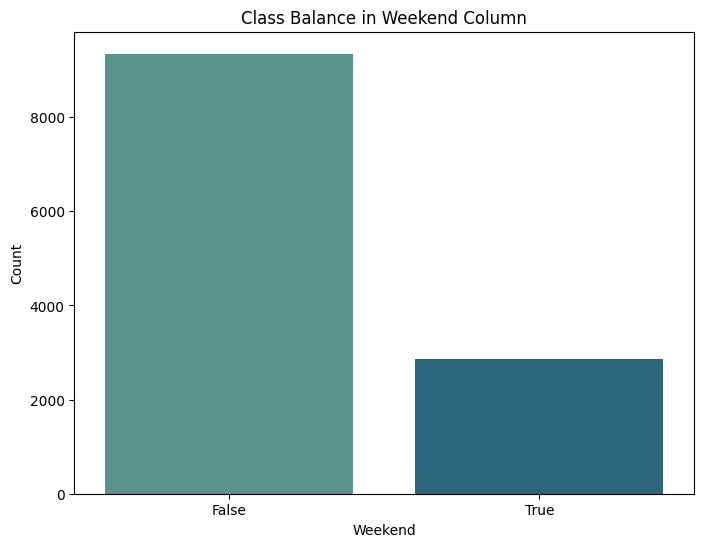

In [ ]:
# bar chart for class balance in our target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='Weekend', data=df, palette='crest')
plt.title('Class Balance in Weekend Column')
plt.xlabel('Weekend')
plt.ylabel('Count')
plt.show()



### Distribution of Key Numerical Features

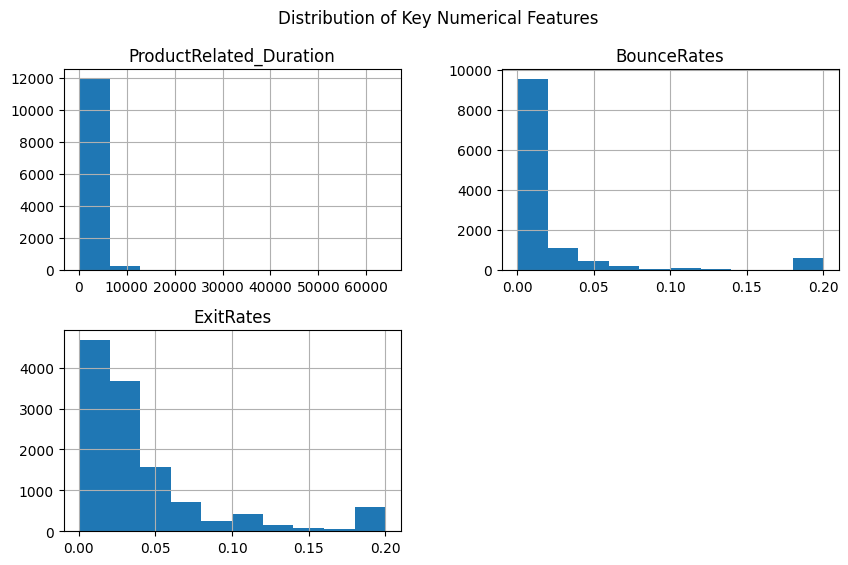

In [ ]:
num_cols = ['ProductRelated_Duration', 'BounceRates', 'ExitRates']

df[num_cols].hist(figsize=(10,6))
plt.suptitle('Distribution of Key Numerical Features')
plt.show()

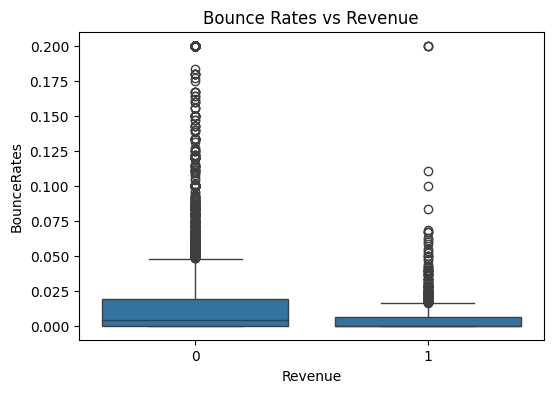

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.title('Bounce Rates vs Revenue')
plt.show()

### Conversion rate by month

In [ ]:
df['Month'].value_counts()

,count
Month,
May,3329
Nov,2982
Mar,1860
Dec,1706
Oct,549
Sep,448
Aug,433
Jul,432
June,285


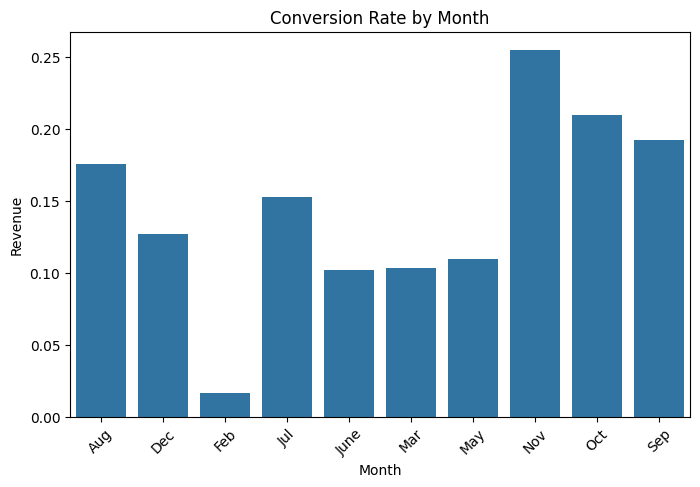

In [ ]:
conversion_by_month = df.groupby('Month')['Revenue'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Month', y='Revenue', data=conversion_by_month)
plt.title('Conversion Rate by Month')
plt.xticks(rotation=45)
plt.show()

### Correlation Heatmap

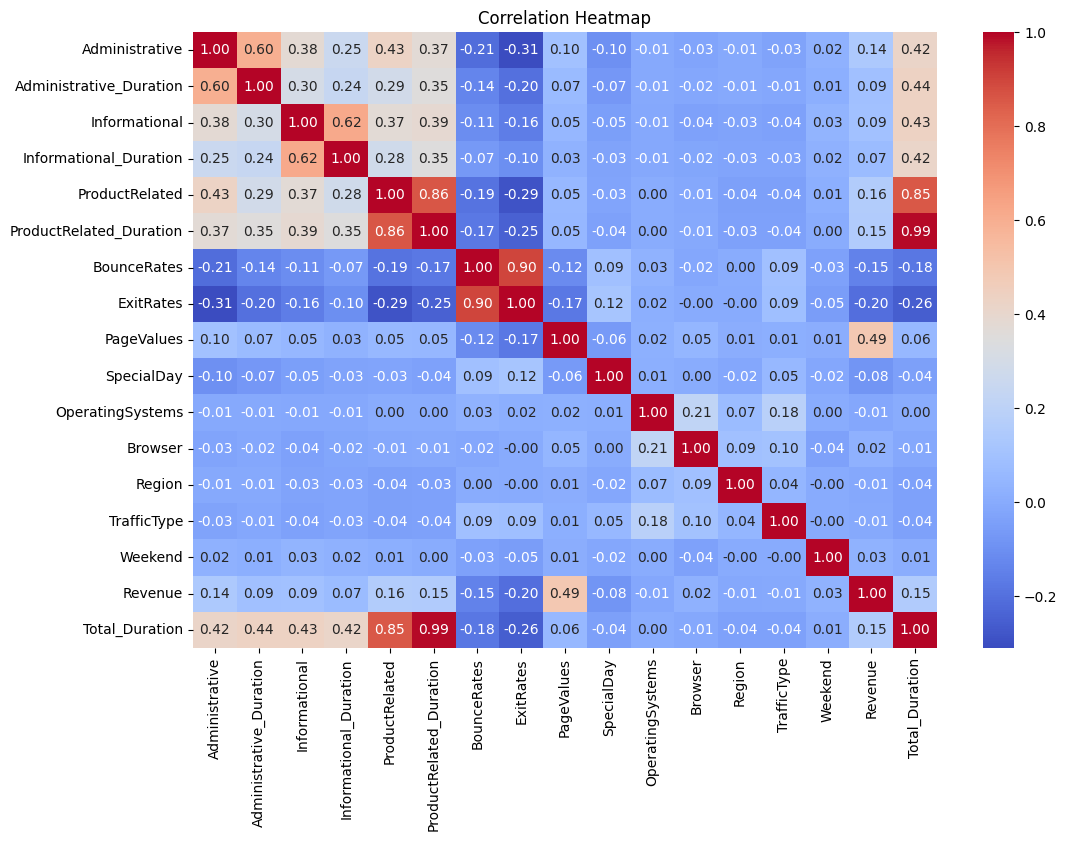

In [ ]:
plt.figure(figsize=(12,8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

In [ ]:
df[['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']].head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
0,0,0.0,0,0.0,1,0.000000
1,0,0.0,0,0.0,2,64.000000
2,0,0.0,0,0.0,1,0.000000
3,0,0.0,0,0.0,2,2.666667
4,0,0.0,0,0.0,10,627.500000


In [ ]:
# correlation matrix against purchses
corr_matrix['Revenue'].sort_values(ascending=False)


,Revenue
Revenue,1.000000
PageValues,0.491894
ProductRelated,0.156042
Total_Duration,0.153720
ProductRelated_Duration,0.150077
Administrative,0.136330
Informational,0.093626
Administrative_Duration,0.091768
Informational_Duration,0.069358
Weekend,0.027729


### One-hot encoding

In [ ]:
# Identify categorical columns to be one-hot encoded
categorical_cols = ['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'SpecialDay']



# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its shape to verify
display(df_encoded.head())
print(f"Shape of DataFrame after encoding: {df_encoded.shape}")

In [ ]:
# Dynamically identify categorical columns after converting them to 'category' dtype
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_cols
# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame and its shape to verify
display(df_encoded.head())
print(f"Shape of DataFrame after encoding: {df_encoded.shape}")

In [ ]:
pip install imbalanced-learn

## MODELING

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Original testing set shape: {X_test.shape}, {y_test.shape}")
print(f"Class distribution in y_train before SMOTE:\n{y_train.value_counts()}")

### Applying SMOTE to the Training Data
SMOTE (Synthetic Minority Over-sampling Technique) will be applied only to the training data to handle the class imbalance. This generates synthetic samples for the minority class.

In [ ]:
# Apply SMOTE to the training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Training set shape after SMOTE: {X_train_res.shape}, {y_train_res.shape}")
print(f"Class distribution in y_train after SMOTE:\n{y_train_res.value_counts()}")

### Scaling Numerical Features
Next, I will scale the numerical features using `StandardScaler`. It's important to fit the scaler only on the training data (`X_train_res`) and then transform both the training and testing data using that fitted scaler to prevent data leakage.

In [ ]:
# Identify numerical columns for scaling dynamically
# Select columns with int64 or float64 dtypes
numerical_cols = X_train_res.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_res[numerical_cols] = scaler.fit_transform(X_train_res[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train_res.head())

### Training and Evaluating a Logistic Regression Model
Now that the data is preprocessed (SMOTE for imbalance, scaling for numerical features), I will train a Logistic Regression model and evaluate its performance using a classification report and confusion matrix.

In [ ]:
# Initialize and train a Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
model.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### Hyperparameter Tuning for Logistic Regression using GridSearchCV
Using`GridSearchCV` to find the best hyperparameters for the Logistic Regression model. This will systematically work through multiple combinations of parameter values, cross-validating each combination to determine which gives the best performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Define the parameter grid with compatible solver-penalty combinations
param_grid = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['liblinear'], 'penalty': ['l1', 'l2']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs'], 'penalty': ['l2']} # lbfgs only supports l2 penalty
]

# Initialize Logistic Regression model
log_reg_tuned = LogisticRegression(random_state=42, max_iter=200)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg_tuned,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1', # Use f1-score as the evaluation metric
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the resampled training data
grid_search.fit(X_train_res, y_train_res)

print(f"Best hyperparameters for Logistic Regression: {grid_search.best_params_}")
print(f"Best F1-score from GridSearchCV: {grid_search.best_score_:.4f}")

# Get the best model
best_log_reg_model = grid_search.best_estimator_

# Make predictions with the tuned Logistic Regression model
y_pred_tuned_log_reg = best_log_reg_model.predict(X_test)

print("\n--- Tuned Logistic Regression Model Evaluation ---")
print("\nConfusion Matrix (Tuned Logistic Regression):")
print(confusion_matrix(y_test, y_pred_tuned_log_reg))

print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test, y_pred_tuned_log_reg))

### Training and Evaluating a Random Forest Classifier
Training a `RandomForestClassifier` on the same preprocessed and balanced training data and evaluate its performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_res, y_train_res)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("\n--- Random Forest Model Evaluation ---")
print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

### Comparison of Models
Finally, let's compare the performance metrics of the initial Logistic Regression model, the tuned Logistic Regression model, and the Random Forest Classifier to identify the best performing model for this task.

In [ ]:
print("\n--- Model Comparison ---")

print("\nInitial Logistic Regression (from previous cell):")
print(classification_report(y_test, y_pred)) # y_pred is from the initial LR model

print("\nTuned Logistic Regression:")
print(classification_report(y_test, y_pred_tuned_log_reg))

print("\nRandom Forest Classifier:")
print(classification_report(y_test, y_pred_rf))

In [ ]:
# visualize confusion matrix for all models
sns.set(style="whitegrid")
plt.figure(figsize=(18, 6))

# Confusion Matrix for Initial Logistic Regression
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
cm_lr = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['No Purchase', 'Purchase'], yticklabels=['No Purchase', 'Purchase'])
plt.title('Initial Logistic Regression\nConfusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Confusion Matrix for Tuned Logistic Regression
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
cm_tuned_lr = confusion_matrix(y_test, y_pred_tuned_log_reg)
sns.heatmap(cm_tuned_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['No Purchase', 'Purchase'], yticklabels=['No Purchase', 'Purchase'])
plt.title('Tuned Logistic Regression\nConfusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Confusion Matrix for Random Forest Classifier
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['No Purchase', 'Purchase'], yticklabels=['No Purchase', 'Purchase'])
plt.title('Random Forest Classifier\nConfusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

### Feature Importance Visualization (Random Forest)
Let's visualize the importance of each feature in the Random Forest model. This can help us understand which factors contribute most to predicting purchase intention.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the Random Forest model
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train_res.columns)

# Select top N features for better visualization
top_n = 15 # You can adjust this number
top_features = feature_importances.nlargest(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='viridis', legend=False)
plt.title('Top 15 Feature Importances from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Cross-Validation for Random Forest Model
To ensure the robustness of the Random Forest model and get a more reliable estimate of its performance, I will perform 5-fold cross-validation on the resampled training data.

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X_train_res, y_train_res, cv=5, scoring='f1', n_jobs=-1)

print(f"Random Forest Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean F1 Score (Cross-Validation): {cv_scores.mean():.4f}")
print(f"Standard Deviation of F1 Scores: {cv_scores.std():.4f}")

### ROC-AUC Score Evaluation for Random Forest Model
Finally, let's evaluate the Random Forest model using the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) score, which is a good metric for binary classification, especially with imbalanced datasets.

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# Predict probabilities for the positive class (class 1)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve (optional, but good for visualization)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()

### Project Summary: Predicting Purchase Intention

**1. Problem Definition:**
Our primary objective was to build machine learning models to predict user purchase intention (a binary classification task: Purchase/No Purchase) using behavior data collected from an online shopping platform.

**2. Data Loading and Initial Exploration:**
*   The dataset `online_shoppers_intention.csv` was loaded.
*   Initial checks revealed 125 duplicate rows, which were subsequently **removed** in cell. No missing (null) values were identified.

**3. Data Preprocessing & Feature Engineering:**
*   The target variable `Revenue` was converted from boolean to numerical (1 for Purchase, 0 for No Purchase).
*   A significant class imbalance was identified in the `Revenue` column: 10297 'No Purchase' vs. 1908 'Purchase' (after dropping duplicates).
*   A new feature, `Total_Duration`, was engineered by summing `Administrative_Duration`, `Informational_Duration`, and `ProductRelated_Duration`.
*   Categorical features (`Month`, `VisitorType`, `Weekend`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, and `SpecialDay`) were dynamically identified using `select_dtypes` (after converting them to 'category' dtype) and then one-hot encoded to prepare them for modeling.

**4. Exploratory Data Analysis (EDA) Insights:**
*   **Visitor Type vs. Conversion:** New Visitors exhibited the highest conversion rate (~24.9%), followed by Other Visitors (~19.8%), while Returning Visitors had the lowest conversion rate (14.1%).
*   **Session Duration vs. Visitor Type:** Paradoxically, Returning Visitors spent significantly more time on the site (1421 seconds) compared to New Visitors (748 seconds) and Other Visitors (677 seconds). This suggests that extended browsing time for returning users doesn't directly translate to higher purchase intent, possibly due to different browsing behaviors (e.g., comparison shopping).

**5. Machine Learning Pipeline & Model Evaluation:**
*   **Data Split:** The dataset was split into 80% training and 20% testing sets, ensuring stratification of the `Revenue` column to maintain class proportions.
*   **Class Imbalance Handling:** SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data to balance the classes.
*   **Feature Scaling:** Numerical features were dynamically identified using `select_dtypes` (`int64`, `float64`) and then scaled using `StandardScaler`.

    **a. Initial Logistic Regression Model:**
    *   **Accuracy:** 88%
    *   **Confusion Matrix:** True Negatives: 1905, False Positives: 154, False Negatives: 139, True Positives: 243.
    *   **Classification Report (F1-score for 'Purchase'):** 0.62 (Precision: 0.61, Recall: 0.64).
    *   **Best at:** Accurately predicting 'No Purchase' (Recall: 0.93), but struggled significantly with identifying actual 'Purchase' sessions (higher False Negatives).

    **b. Tuned Logistic Regression Model (using GridSearchCV):**
    *   **Best Hyperparameters:** `{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}`.
    *   **Accuracy:** 88%
    *   **Confusion Matrix:** True Negatives: 1890, False Positives: 169, False Negatives: 130, True Positives: 252.
    *   **Classification Report (F1-score for 'Purchase'):** 0.63 (Precision: 0.60, Recall: 0.66).
    *   **Best at:** Showed a slight improvement in identifying 'Purchase' sessions (higher Recall and F1-score for class 1) compared to the initial model, demonstrating the value of hyperparameter tuning for the minority class.

    **c. Random Forest Classifier:**
    *   **Accuracy:** 89%
    *   **Confusion Matrix:** True Negatives: 1905, False Positives: 154, False Negatives: 105, True Positives: 277.
    *   **Classification Report (F1-score for 'Purchase'):** 0.68 (Precision: 0.64, Recall: 0.73).
    *   **Cross-Validation F1 Scores:** Mean 0.9350 (Standard Deviation: 0.0453), indicating strong robustness and consistent performance.
    *   **ROC-AUC Score:** 0.9244, signifying excellent discriminatory power between classes.
    *   **Best at:** Overall, the Random Forest Classifier demonstrated the best performance across all evaluated metrics, particularly excelling in balancing precision and recall for the minority 'Purchase' class, achieving the highest accuracy and F1-score for this class among the models tested.

**6. Feature Importance (Random Forest):**
    The Random Forest model provided insights into the most influential features:
    1.  **PageValues:** (Highly important) - Indicates the value a user has accumulated from visiting certain pages.
    
    2.  **ExitRates:** How frequently users exit from a page after visiting it.
    3.  **Month_Nov:** Indicates a strong correlation with purchase intention during November (likely due to major shopping events).
    4.  **ProductRelated_Duration:** Time spent on product-related pages.
    5.  **Total_Duration:** The total time spent on administrative, informational, and product-related pages.
    6.  **Administrative_Duration:** Time spent on administrative pages.
    7.  **ProductRelated:** Number of product-related pages visited.
    8.  **BounceRates:** How frequently users leave the site from the entry page.
    9.  **Administrative:** Number of administrative pages visited.
    10. **Region:** The geographical region of the user.
    These features highlight that user engagement (duration, page values) and navigation patterns (exit/bounce rates) are critical predictors, along with specific temporal and technical factors.

**Overall Conclusion:**
The **Random Forest Classifier** emerged as the superior model for predicting purchase intention in this dataset, demonstrating robust performance and higher predictive power for the 'Purchase' class compared to both the initial and tuned Logistic Regression models. The feature importance analysis provides actionable insights into the key drivers of purchase behavior.

**Potential Next Steps:**
*   Further fine-tune the Random Forest model's hyperparameters for marginal gains.
*   Explore other advanced ensemble models (e.g., Gradient Boosting machines like XGBoost/LightGBM).
*   Conduct a deeper investigation into the 'paradox' of returning visitors to understand their behavior better.

In [ ]:
# fine-tune the Random Forest model's hyperparameters for marginal gains
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': [10, 20, 30, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required at each leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3, # Using 3-fold cross-validation for quicker execution, can be increased to 5 for more robustness
    scoring='f1', # Use f1-score as the evaluation metric
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Fit GridSearchCV to the resampled training data
grid_search_rf.fit(X_train_res, y_train_res)

print(f"Best hyperparameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best F1-score from GridSearchCV (Random Forest): {grid_search_rf.best_score_:.4f}")

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

# Make predictions with the tuned Random Forest model
y_pred_tuned_rf = best_rf_model.predict(X_test)

print("\n--- Tuned Random Forest Model Evaluation ---")
print("\nConfusion Matrix (Tuned Random Forest):")
print(confusion_matrix(y_test, y_pred_tuned_rf))

print("\nClassification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_tuned_rf))